## **Layer 3 Decision & Policy Layer**

In [1]:
import sys
assert sys.version_info >= (3, 5)

# Scikit-Learn ≥0.20 is required
import sklearn
assert sklearn.__version__ >= "0.20"

# Common imports
import os
import numpy as np
import pandas as pd
import seaborn as sns
import pandas_ta as ta

# to make this notebook's output stable across runs
np.random.seed(42)

# To plot pretty figures
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rc('axes', labelsize=14)
mpl.rc('xtick', labelsize=12)
mpl.rc('ytick', labelsize=12)

current_working_dir = os.getcwd()
if os.path.basename(current_working_dir) == "layers":
    PROJECT_ROOT = os.path.abspath(os.path.join(current_working_dir, ".."))
else:
    PROJECT_ROOT = current_working_dir

if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

# Define data path
DATA_DIR = os.path.join(PROJECT_ROOT, "data")
# Load the data that now includes signals
SIGNALS_DATA_FILE = os.path.join(DATA_DIR, "market_data_signals.parquet")

print(f"Project root set to: {PROJECT_ROOT}")
print(f"Loading data with signals from: {SIGNALS_DATA_FILE}")

try:
    # Load the data processed by Layer 1 and Layer 2
    df = pd.read_parquet(SIGNALS_DATA_FILE)
    print("Successfully loaded data with signals.")
except FileNotFoundError:
    print("Error: Data file 'market_data_signals.parquet' not found.")
    print("Please ensure Layer 1 and Layer 2 notebooks have been run and saved the data.")
    df = pd.DataFrame()

if not df.empty:
    print("\nVerifying required columns ('regime', 'signal'):")
    print(df[['datetime', 'close', 'regime', 'signal']].head())

Project root set to: /Users/raoabdul/Documents/Development/Trading-Bot-Algo
Loading data with signals from: /Users/raoabdul/Documents/Development/Trading-Bot-Algo/data/market_data_signals.parquet
Successfully loaded data with signals.

Verifying required columns ('regime', 'signal'):
                   datetime       close               regime   signal
0 2026-01-12 14:43:00+00:00  257.140015              Unknown  Neutral
1 2026-01-12 14:44:00+00:00  257.549988  Downtrend - Impulse  Neutral
2 2026-01-12 14:45:00+00:00  257.774994    Downtrend - Rally  Bearish
3 2026-01-12 14:46:00+00:00  258.200012    Downtrend - Rally  Bearish
4 2026-01-12 14:47:00+00:00  258.109985    Downtrend - Rally  Bearish


## **Backtest Simulation**

In [7]:
if not df.empty:
    # --- Backtest Configuration ---
    initial_capital = 100000.0
    
    # --- State Tracking ---
    df['position'] = 0  # 1 if holding a share, 0 otherwise
    df['cash'] = initial_capital
    df['portfolio_value'] = initial_capital

    # --- Transaction Log ---
    trades_log = [] # List to store details of each trade
    buy_price_for_current_position = 0.0 # Track the cost of held share
    trade_counter = 0

    # --- Simulation Loop ---
    for i in range(1, len(df)):
        # Carry over previous day's state
        df.loc[i, 'cash'] = df.loc[i-1, 'cash']
        df.loc[i, 'position'] = df.loc[i-1, 'position']

        signal = df.loc[i, 'signal']
        current_close_price = df.loc[i, 'close']
        prev_position = df.loc[i-1, 'position']

        # --- Apply Layer 3: Decision & Policy Logic ---
        
        # Rule 1: BUY logic
        if signal == 'Bullish' and prev_position == 0:
            if df.loc[i, 'cash'] >= current_close_price:
                trade_counter += 1
                df.loc[i, 'position'] = 1
                df.loc[i, 'cash'] -= current_close_price
                buy_price_for_current_position = current_close_price
                
                trades_log.append({
                    'Trade #': trade_counter,
                    'Type': 'BUY',
                    'Entry Date': df.loc[i, 'datetime'],
                    'Entry Price': current_close_price,
                    'Exit Date': pd.NaT,
                    'Exit Price': np.nan,
                    'P/L ($)': np.nan,
                    'P/L (%)': np.nan,
                    'Signal': signal,
                    'Regime': df.loc[i, 'regime'],
                    'Portfolio Value After Trade': df.loc[i, 'cash'] + (df.loc[i, 'position'] * current_close_price)
                })

        # Rule 2: SELL logic
        elif signal == 'Bearish' and prev_position == 1:
            trade_counter += 1
            df.loc[i, 'position'] = 0
            df.loc[i, 'cash'] += current_close_price

            pnl_dollars = current_close_price - buy_price_for_current_position
            pnl_percent = (pnl_dollars / buy_price_for_current_position) * 100

            trades_log.append({
                'Trade #': trade_counter,
                'Type': 'SELL',
                'Entry Date': pd.NaT, 
                'Entry Price': buy_price_for_current_position,
                'Exit Date': df.loc[i, 'datetime'],
                'Exit Price': current_close_price,
                'P/L ($)': pnl_dollars,
                'P/L (%)': pnl_percent,
                'Signal': signal,
                'Regime': df.loc[i, 'regime'],
                'Portfolio Value After Trade': df.loc[i, 'cash'] + (df.loc[i, 'position'] * current_close_price)
            })
            buy_price_for_current_position = 0.0 # Reset

        # Update total portfolio value
        df.loc[i, 'portfolio_value'] = df.loc[i, 'cash'] + (df.loc[i, 'position'] * current_close_price)
    
    print("Backtest simulation complete.")

    # --- Display Transaction Log ---
    trades_df = pd.DataFrame(trades_log)

    print("\n--- Transaction by Transaction Overview ---")
    if not trades_df.empty:
        trades_df_display = trades_df[[
            'Trade #', 'Type', 'Entry Date', 'Entry Price', 
            'Exit Date', 'Exit Price', 'P/L ($)', 'P/L (%)', 
            'Signal', 'Regime'
        ]].copy()
        
        # Format for readability
        trades_df_display['Entry Price'] = trades_df_display['Entry Price'].map('${:,.2f}'.format)
        trades_df_display['Exit Price'] = trades_df_display['Exit Price'].map('${:,.2f}'.format)
        trades_df_display['P/L ($)'] = trades_df_display['P/L ($)'].map('${:,.2f}'.format)
        trades_df_display['P/L (%)'] = trades_df_display['P/L (%)'].map('{:.2f}%'.format)

        print(trades_df_display.to_string())
    else:
        print("No trades were executed during the backtest.")

else:
    print("DataFrame is empty, cannot run backtest.")

Backtest simulation complete.

--- Transaction by Transaction Overview ---
    Trade #  Type                Entry Date Entry Price                 Exit Date Exit Price P/L ($) P/L (%)   Signal              Regime
0         1   BUY 2026-01-12 15:16:00+00:00     $259.23                       NaT       $nan    $nan    nan%  Bullish  Uptrend - Pullback
1         2  SELL                       NaT     $259.23 2026-01-12 15:25:00+00:00    $259.34   $0.11   0.04%  Bearish   Downtrend - Rally
2         3   BUY 2026-01-12 15:31:00+00:00     $259.43                       NaT       $nan    $nan    nan%  Bullish  Uptrend - Pullback
3         4  SELL                       NaT     $259.43 2026-01-12 15:41:00+00:00    $259.87   $0.43   0.17%  Bearish   Downtrend - Rally
4         5   BUY 2026-01-12 15:45:00+00:00     $259.63                       NaT       $nan    $nan    nan%  Bullish  Uptrend - Pullback
5         6  SELL                       NaT     $259.63 2026-01-12 15:54:00+00:00    $259.58  $-0

## **Performance Analysis and Visualization**


--- Backtest Performance Metrics ---
Initial Capital:          $100,000.00
Final Portfolio Value:    $100,000.89
Strategy Total Return:    0.00%
Buy & Hold Total Return:  1.19%
Maximum Drawdown:         -0.00%


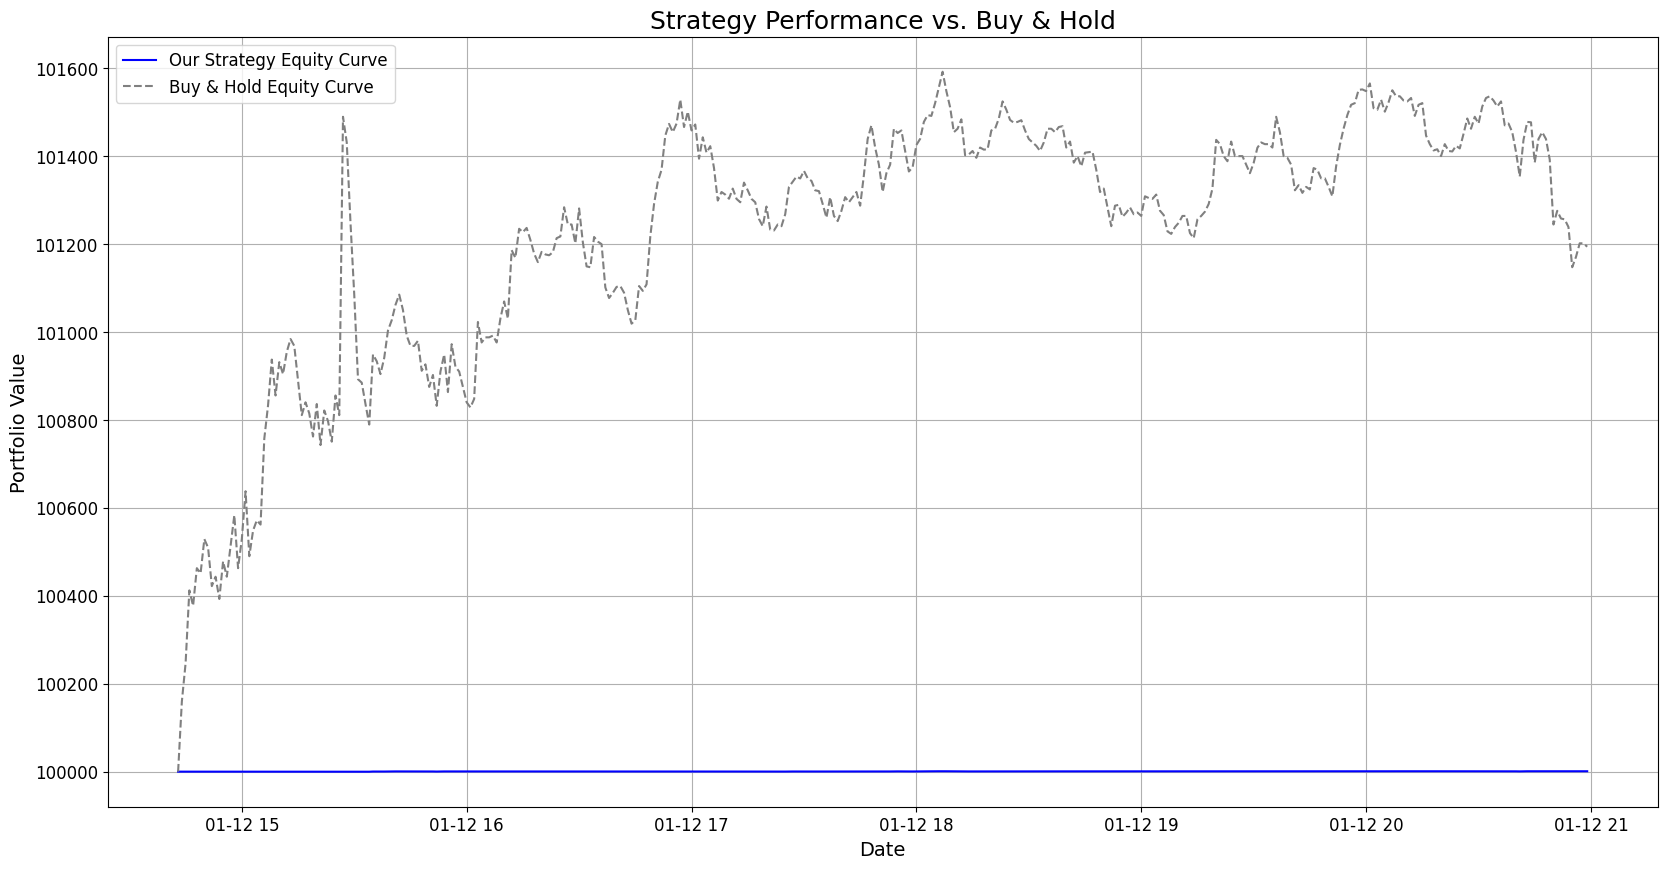

In [9]:
if not df.empty:
    # --- Performance Metrics (Layer 4) ---
    final_portfolio_value = df['portfolio_value'].iloc[-1]
    total_return_pct = ((final_portfolio_value / initial_capital) - 1) * 100
    
    # Calculate Buy & Hold return for comparison
    buy_hold_return_pct = ((df['close'].iloc[-1] / df['close'].iloc[0]) - 1) * 100
    
    # Calculate Max Drawdown (critical risk metric)
    rolling_max = df['portfolio_value'].cummax()  # Get the running maximum
    daily_drawdown = df['portfolio_value'] / rolling_max - 1.0  # Calculate daily drawdown
    max_drawdown_pct = daily_drawdown.min() * 100  # Find the largest drawdown

    print("\n--- Backtest Performance Metrics ---")
    print(f"Initial Capital:          ${initial_capital:,.2f}")
    print(f"Final Portfolio Value:    ${final_portfolio_value:,.2f}")
    print(f"Strategy Total Return:    {total_return_pct:.2f}%")
    print(f"Buy & Hold Total Return:  {buy_hold_return_pct:.2f}%")
    print(f"Maximum Drawdown:         {max_drawdown_pct:.2f}%")
    
    # --- Visualization ---
    plt.figure(figsize=(20, 10))
    
    # Plot our strategy's equity curve
    plt.plot(df['datetime'], df['portfolio_value'], label='Our Strategy Equity Curve', color='blue')
    
    # Plot Buy & Hold equity curve for comparison
    buy_hold_equity = (df['close'] / df['close'].iloc[0]) * initial_capital
    plt.plot(df['datetime'], buy_hold_equity, label='Buy & Hold Equity Curve', color='gray', linestyle='--')
    
    plt.title('Strategy Performance vs. Buy & Hold', fontsize=18)
    plt.xlabel('Date', fontsize=14)
    plt.ylabel('Portfolio Value', fontsize=14)
    plt.legend(loc='upper left', fontsize=12)
    plt.grid(True)
    plt.show()

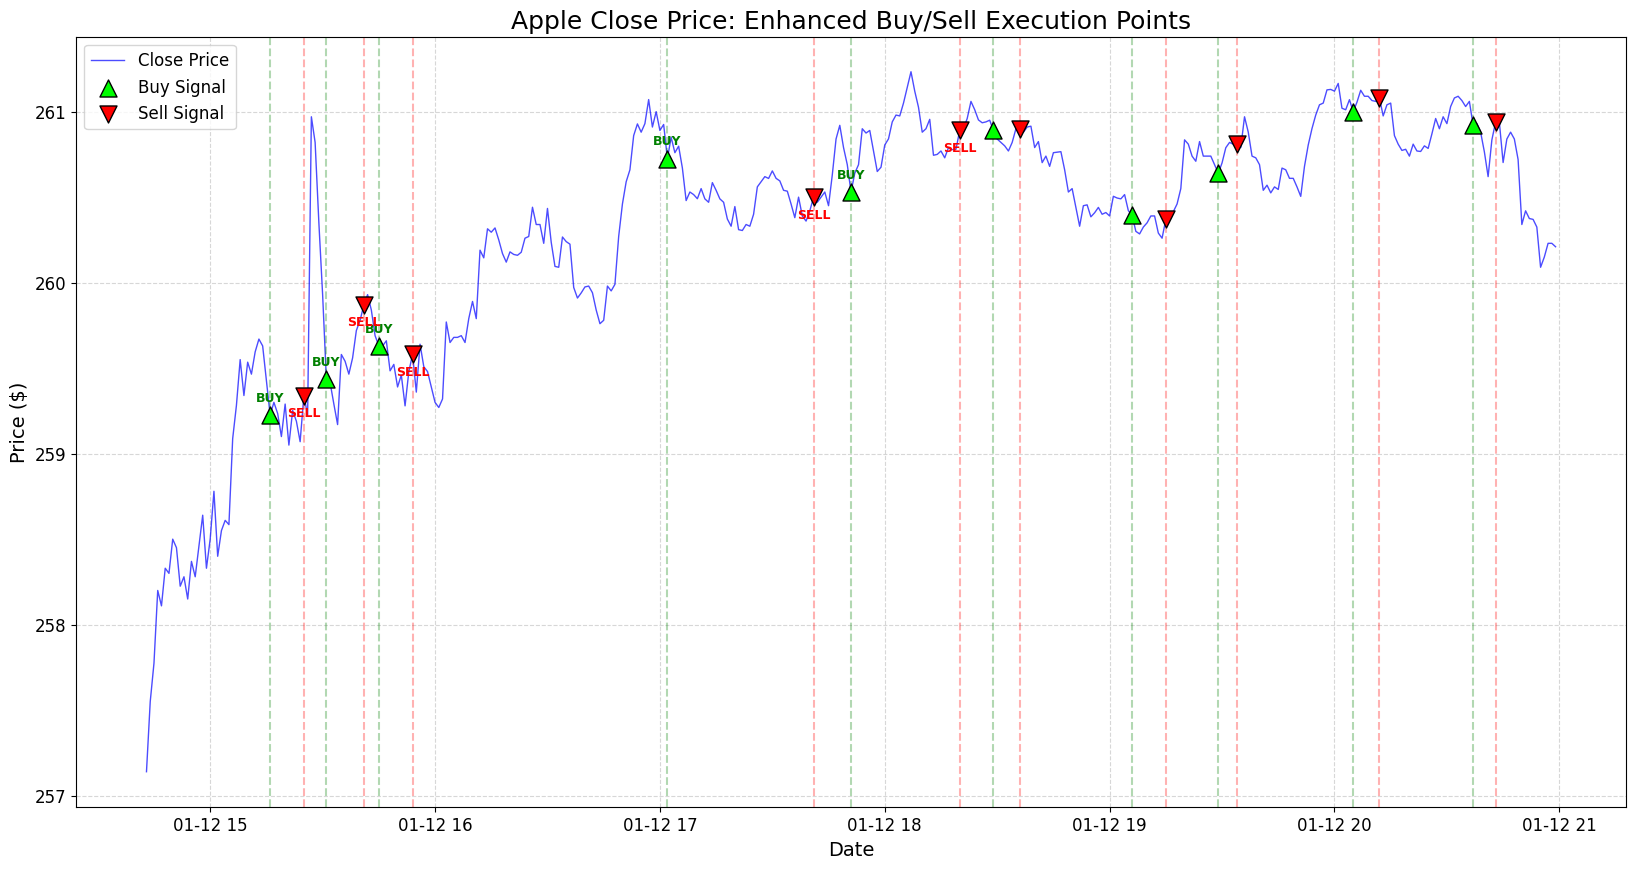

In [10]:
if not df.empty:
    plt.figure(figsize=(20, 10))
    
    # 1. Plot the Close Price (thinner line to make markers pop)
    plt.plot(df['datetime'], df['close'], label='Close Price', color='blue', linewidth=1, alpha=0.7)
    
    # 2. Identify Signals
    buy_signals = df[(df['position'].shift(1) == 0) & (df['position'] == 1)]
    sell_signals = df[(df['position'].shift(1) == 1) & (df['position'] == 0)]
    
    # 3. Enhanced Buy Highlights
    plt.scatter(buy_signals['datetime'], buy_signals['close'], marker='^', 
                color='lime', s=150, label='Buy Signal', edgecolors='black', zorder=5)
    
    # Add vertical dashed lines for Buy
    for x in buy_signals['datetime']:
        plt.axvline(x, color='green', linestyle='--', alpha=0.3)

    # 4. Enhanced Sell Highlights
    plt.scatter(sell_signals['datetime'], sell_signals['close'], marker='v', 
                color='red', s=150, label='Sell Signal', edgecolors='black', zorder=5)
    
    # Add vertical dashed lines for Sell
    for x in sell_signals['datetime']:
        plt.axvline(x, color='red', linestyle='--', alpha=0.3)

    # 5. Add Text Annotations for the first few signals (optional)
    for idx, row in buy_signals.head(5).iterrows():
        plt.annotate('BUY', (row['datetime'], row['close']), 
                     textcoords="offset points", xytext=(0, 10), ha='center', 
                     fontsize=9, fontweight='bold', color='green')

    for idx, row in sell_signals.head(5).iterrows():
        plt.annotate('SELL', (row['datetime'], row['close']), 
                     textcoords="offset points", xytext=(0, -15), ha='center', 
                     fontsize=9, fontweight='bold', color='red')
    
    # Chart Styling
    plt.title('Apple Close Price: Enhanced Buy/Sell Execution Points', fontsize=18)
    plt.xlabel('Date', fontsize=14)
    plt.ylabel('Price ($)', fontsize=14)
    plt.legend(loc='upper left', fontsize=12)
    plt.grid(True, which='both', linestyle='--', alpha=0.5)
    
    plt.show()

In [11]:
if not df.empty:
     num_buys = df[(df['position'].shift(1) == 0) & (df['position'] == 1)].shape[0]
     num_sells = df[(df['position'].shift(1) == 1) & (df['position'] == 0)].shape[0]
     
     print("\n--- Trading Activity Summary ---")
     print(f"Number of Buy Trades: {num_buys}")
     print(f"Number of Sell Trades: {num_sells}")
     print(f"Total Trades: {num_buys + num_sells}")


--- Trading Activity Summary ---
Number of Buy Trades: 10
Number of Sell Trades: 10
Total Trades: 20
